In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("diabetic_data.csv")

## Data Understanding

In [4]:
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
encounter_id,2278392,149190,64410,500364,16680,35754,55842,63768,12522,15738
patient_nbr,8222157,55629189,86047875,82442376,42519267,82637451,84259809,114882984,48330783,63555939
race,Caucasian,Caucasian,AfricanAmerican,Caucasian,Caucasian,Caucasian,Caucasian,Caucasian,Caucasian,Caucasian
gender,Female,Female,Female,Male,Male,Male,Male,Male,Female,Female
age,[0-10),[10-20),[20-30),[30-40),[40-50),[50-60),[60-70),[70-80),[80-90),[90-100)
weight,?,?,?,?,?,?,?,?,?,?
admission_type_id,6,1,1,1,1,2,3,1,2,3
discharge_disposition_id,25,1,1,1,1,1,1,1,1,3
admission_source_id,1,7,7,7,7,2,2,7,4,4
time_in_hospital,1,3,2,2,1,3,4,5,13,12


In [5]:
df.shape

(101766, 50)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [7]:
df.replace('?',np.nan,inplace=True)

In [8]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [9]:
(df.isna().sum() / len(df)).sort_values(ascending=False)

weight                      0.968585
max_glu_serum               0.947468
A1Cresult                   0.832773
medical_specialty           0.490822
payer_code                  0.395574
race                        0.022336
diag_3                      0.013983
diag_2                      0.003518
diag_1                      0.000206
encounter_id                0.000000
troglitazone                0.000000
tolbutamide                 0.000000
pioglitazone                0.000000
rosiglitazone               0.000000
acarbose                    0.000000
miglitol                    0.000000
citoglipton                 0.000000
tolazamide                  0.000000
examide                     0.000000
glipizide                   0.000000
insulin                     0.000000
glyburide-metformin         0.000000
glipizide-metformin         0.000000
glimepiride-pioglitazone    0.000000
metformin-rosiglitazone     0.000000
metformin-pioglitazone      0.000000
change                      0.000000
d

In [10]:
# To distengish between numerical and categorical features
categorical_cols= df.select_dtypes(include='object').columns
print(f"total categorical: {len(categorical_cols)}")
print(f"categorical: {categorical_cols} \n ")

numerical_cols= df.select_dtypes(include='number').columns
print(f"total numerical: {len(numerical_cols)}")
print(f"numerical: {numerical_cols} \n ")

total categorical: 37
categorical: Index(['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty',
       'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object') 
 
total numerical: 13
numerical: Index(['encounter_id', 'patient_nbr', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient',
       'number_diagn

In [11]:
#to explore the output of each featruer
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}\n")

race: ['Caucasian' 'AfricanAmerican' nan 'Other' 'Asian' 'Hispanic']

gender: ['Female' 'Male' 'Unknown/Invalid']

age: ['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']

weight: [nan '[75-100)' '[50-75)' '[0-25)' '[100-125)' '[25-50)' '[125-150)'
 '[175-200)' '[150-175)' '>200']

payer_code: [nan 'MC' 'MD' 'HM' 'UN' 'BC' 'SP' 'CP' 'SI' 'DM' 'CM' 'CH' 'PO' 'WC' 'OT'
 'OG' 'MP' 'FR']

medical_specialty: ['Pediatrics-Endocrinology' nan 'InternalMedicine'
 'Family/GeneralPractice' 'Cardiology' 'Surgery-General' 'Orthopedics'
 'Gastroenterology' 'Surgery-Cardiovascular/Thoracic' 'Nephrology'
 'Orthopedics-Reconstructive' 'Psychiatry' 'Emergency/Trauma'
 'Pulmonology' 'Surgery-Neuro' 'Obsterics&Gynecology-GynecologicOnco'
 'ObstetricsandGynecology' 'Pediatrics' 'Hematology/Oncology'
 'Otolaryngology' 'Surgery-Colon&Rectal' 'Pediatrics-CriticalCare'
 'Endocrinology' 'Urology' 'Psychiatry-Child/Adolescent'
 'Pediatrics-Pulmonology' 'Neurolo

In [12]:
# delete the feature with uniqe one output
constant_cat = [col for col in categorical_cols if df[col].nunique() <= 1]
binary_cat   = [col for col in categorical_cols if df[col].nunique() == 2]
multi_cat    = [col for col in categorical_cols if df[col].nunique() >= 3]

print("Constant categorical variables (≤1 unique value):")
print(constant_cat)

print("\nBinary categorical variables (2 unique values):")
print(binary_cat)

print("\nMulti-level categorical variables (≥3 unique values):")
print(multi_cat)

Constant categorical variables (≤1 unique value):
['examide', 'citoglipton']

Binary categorical variables (2 unique values):
['acetohexamide', 'tolbutamide', 'troglitazone', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']

Multi-level categorical variables (≥3 unique values):
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'tolazamide', 'insulin', 'glyburide-metformin', 'readmitted']


In [13]:
# gender was coded differently so we use a custom count for this one
print(f"gender: { (df['gender'] == 'Unknown/Invalid').sum() }")

gender: 3


In [14]:
df.patient_nbr.value_counts()

patient_nbr
88785891     40
43140906     28
1660293      23
88227540     23
23199021     23
             ..
11005362      1
98252496      1
1019673       1
13396320      1
175429310     1
Name: count, Length: 71518, dtype: int64

some of these observations are dependent on each other because there can exist more than one patient encounter per patient:

## data cleaning

### categorical

from understanding data we have:                                                                                                             
**Weight** has 96.85% of the missing values so there is no significance in filling those missing values so we decided to drop this variable                                      
**payer_code** has 39.55% missing values that means we can drop this column             
**medical_specialty** has 49.08% missing values that means we can drop this column but it is usfel so we will do to type of preprocessing one for logistic drop it , and one for tree-based make it as Unknown                                                          
**examide** & **citoglipton** all records have the same value. So essentially these cannot provide any interpretive or discriminatory information for predicting readmission                                                                                                       
**max_glu_serum** & **A1Cresult** both have a value could None and that value consider as null value , but it is actully not                   
**race** have 2.23% missing value , so we can make it as Unknown                                                                               
**diag_3**  0.013983 **diag_2** 0.003518 **diag_1** 0.000206  it is small we could drop it or make it as Unknown                                      


#### Drop

In [20]:
# dropping columns with large number of missing values
df = df.drop(['weight', 'payer_code'], axis = 1)
# dropping columns with constant output
df = df.drop(['examide','citoglipton'], axis = 1)

#### medical_specialty

In [22]:
df['medical_specialty'].value_counts()

medical_specialty
InternalMedicine                    14635
Emergency/Trauma                     7565
Family/GeneralPractice               7440
Cardiology                           5352
Surgery-General                      3099
                                    ...  
Perinatology                            1
Neurophysiology                         1
Psychiatry-Addictive                    1
Pediatrics-InfectiousDiseases           1
Surgery-PlasticwithinHeadandNeck        1
Name: count, Length: 72, dtype: int64

In [23]:
df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')

#### race

In [25]:
df["race"].value_counts()

race
Caucasian          76099
AfricanAmerican    19210
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [26]:
df['race'] = df['race'].fillna('Unknown')

In [27]:
df["race"].value_counts()

race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

#### gender

In [29]:
df['gender'].value_counts()

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

In [30]:
df['gender'] = df['gender'].replace('Unknown/Invalid', np.nan)
df = df.dropna(subset=['gender'])
df['gender'].value_counts()

gender
Female    54708
Male      47055
Name: count, dtype: int64

#### max_glu_serum and A1Cresult

In [32]:
'''In the original dataset have  values in max_glu_serum and A1Cresult columns
called 'none' (the test was not done) automatically converted to NaN by pandas
when reading the CSV. To preserve this information, we treat all missing values (NaN)
replace them with the string 'None' '''

df['max_glu_serum'] = df['max_glu_serum'].fillna('None')
df['A1Cresult'] = df['max_glu_serum'].fillna('None')

In [33]:
df['max_glu_serum'].value_counts() , df['A1Cresult'].value_counts()

(max_glu_serum
 None    96417
 Norm     2597
 >200     1485
 >300     1264
 Name: count, dtype: int64,
 A1Cresult
 None    96417
 Norm     2597
 >200     1485
 >300     1264
 Name: count, dtype: int64)

In [34]:
print(df['A1Cresult'].isna().sum())
print(df['max_glu_serum'].isna().sum())

0
0


#### diagonisis

In [36]:
df.loc[df.diag_1.isna(), ['diag_1', 'diag_2', 'diag_3']]

,diag_1,diag_2,diag_3
518,NaN,780,997
1006,NaN,595,250.6
1267,NaN,250.82,401
1488,NaN,276,594
3197,NaN,250.01,428
7845,NaN,496,788
14503,NaN,276,250.01
19714,NaN,112,585
32514,NaN,998,427
37693,NaN,780,295


In [37]:
df[["diag_1", "diag_2", "diag_3"]] = df[["diag_1", "diag_2", "diag_3"]].fillna("Unknown")

In [38]:
print(df.isnull().sum().any())

False


## Categorical

### EDA

In [41]:
df['readmitted'].value_counts()

readmitted
NO     54861
>30    35545
<30    11357
Name: count, dtype: int64

C:\Users\User\AppData\Local\Temp\ipykernel_14052\2249167923.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='readmitted',palette= 'Set2')


<Axes: xlabel='readmitted', ylabel='count'>

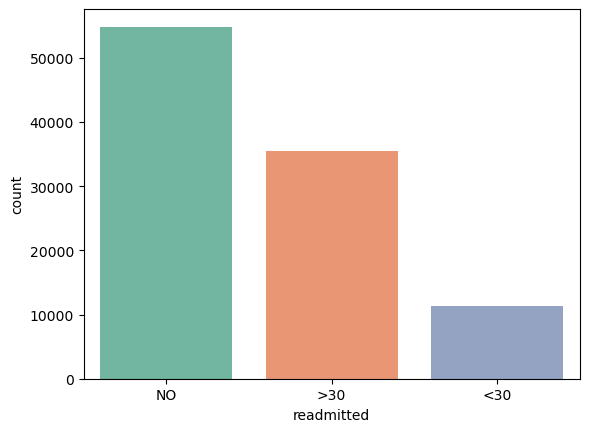

In [42]:
# Distribution of Readmission
sns.countplot(data=df, x='readmitted',palette= 'Set2')

In [43]:
df['readmitted'] = df['readmitted'].replace({'>30': 0, 'NO': 0, '<30': 1})

C:\Users\User\AppData\Local\Temp\ipykernel_14052\896549085.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['readmitted'] = df['readmitted'].replace({'>30': 0, 'NO': 0, '<30': 1})


In [44]:
df['readmitted'].value_counts()

readmitted
0    90406
1    11357
Name: count, dtype: int64

C:\Users\User\AppData\Local\Temp\ipykernel_14052\102362902.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='readmitted', order=[0,1], palette='Set2').set_xticklabels(['Not readmitted (30 days)', 'Readmitted (30 days)'])
C:\Users\User\AppData\Local\Temp\ipykernel_14052\102362902.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  sns.countplot(data=df, x='readmitted', order=[0,1], palette='Set2').set_xticklabels(['Not readmitted (30 days)', 'Readmitted (30 days)'])


[Text(0, 0, 'Not readmitted (30 days)'), Text(1, 0, 'Readmitted (30 days)')]

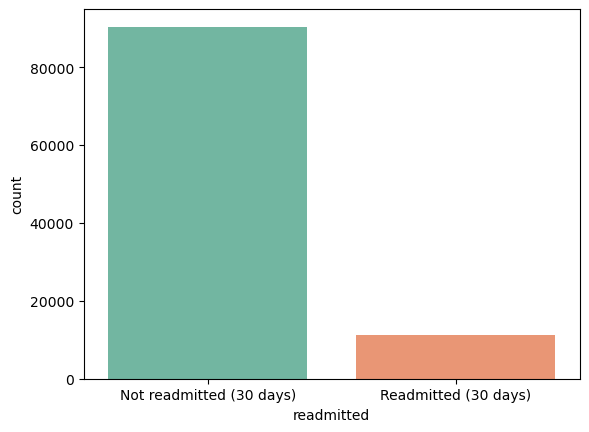

In [45]:
# Distribution of Readmission
sns.countplot(data=df, x='readmitted', order=[0,1], palette='Set2').set_xticklabels(['Not readmitted (30 days)', 'Readmitted (30 days)'])

C:\Users\User\AppData\Local\Temp\ipykernel_14052\2542698458.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='gender',palette= 'Set2')


<Axes: xlabel='gender', ylabel='count'>

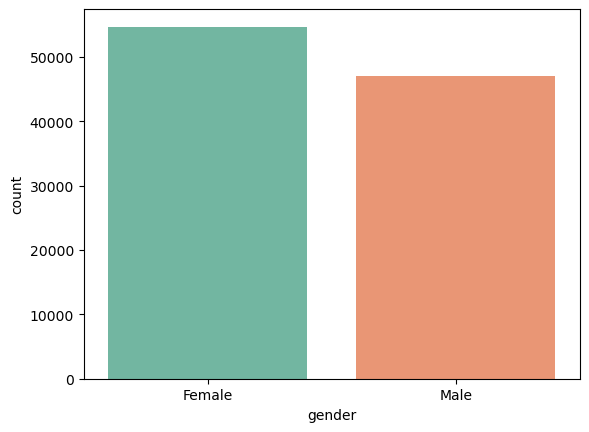

In [46]:
sns.countplot(data=df, x='gender',palette= 'Set2')

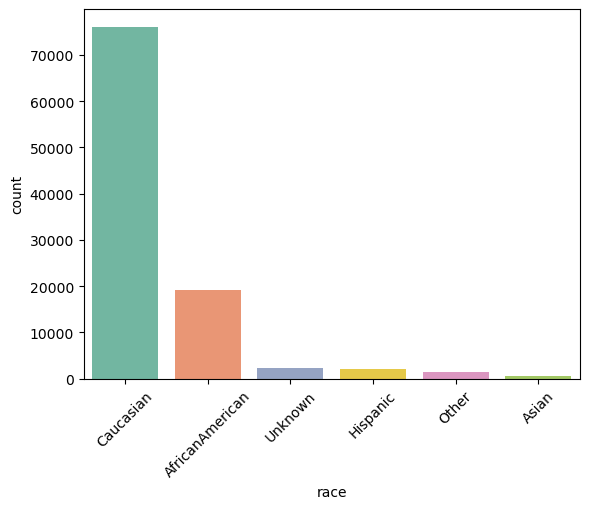

In [47]:
order = df['race'].value_counts(ascending=False).index

# 2. Create the plot
# Using x='race' as you requested, but note that labels may overlap if names are long
sns.countplot(
    data=df,
    x='race',
    palette='Set2',
    order=order,
    hue='race',     # Assigning hue to race for compatibility
    legend=False    # Removes the redundant legend
)

# Optional: Rotate labels if they overlap
plt.xticks(rotation=45)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_14052\1351830522.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='age', palette='Set2')


<Axes: xlabel='age', ylabel='count'>

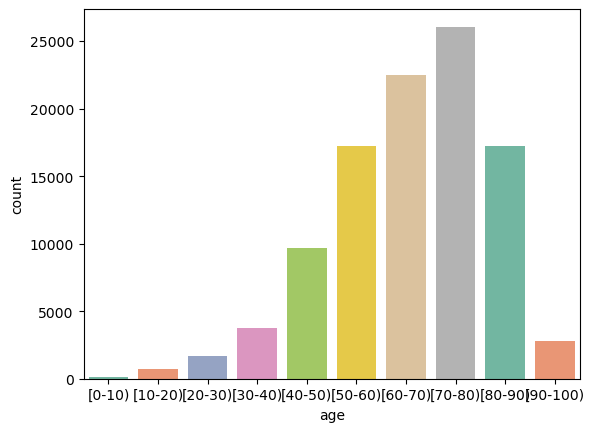

In [48]:
sns.countplot(data=df, x='age', palette='Set2')

In [49]:
# List all drug columns
drug = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide',
    'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]


In [50]:
for i in drug:
    print(i, df[i].unique())

metformin ['No' 'Steady' 'Up' 'Down']
repaglinide ['No' 'Up' 'Steady' 'Down']
nateglinide ['No' 'Steady' 'Down' 'Up']
chlorpropamide ['No' 'Steady' 'Down' 'Up']
glimepiride ['No' 'Steady' 'Down' 'Up']
acetohexamide ['No' 'Steady']
glipizide ['No' 'Steady' 'Up' 'Down']
glyburide ['No' 'Steady' 'Up' 'Down']
tolbutamide ['No' 'Steady']
pioglitazone ['No' 'Steady' 'Up' 'Down']
rosiglitazone ['No' 'Steady' 'Up' 'Down']
acarbose ['No' 'Steady' 'Up' 'Down']
miglitol ['No' 'Steady' 'Down' 'Up']
troglitazone ['No' 'Steady']
tolazamide ['No' 'Steady' 'Up']
insulin ['No' 'Up' 'Steady' 'Down']
glyburide-metformin ['No' 'Steady' 'Down' 'Up']
glipizide-metformin ['No' 'Steady']
glimepiride-pioglitazone ['No' 'Steady']
metformin-rosiglitazone ['No' 'Steady']
metformin-pioglitazone ['No' 'Steady']


C:\Users\User\AppData\Local\Temp\ipykernel_14052\3916495437.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, ax=axs[idx], palette='Set2')
C:\Users\User\AppData\Local\Temp\ipykernel_14052\3916495437.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, ax=axs[idx], palette='Set2')
C:\Users\User\AppData\Local\Temp\ipykernel_14052\3916495437.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, ax=axs[idx], palette='Set2')
C:\Users\User\AppData\Local\Temp\ipykernel_14052\391649

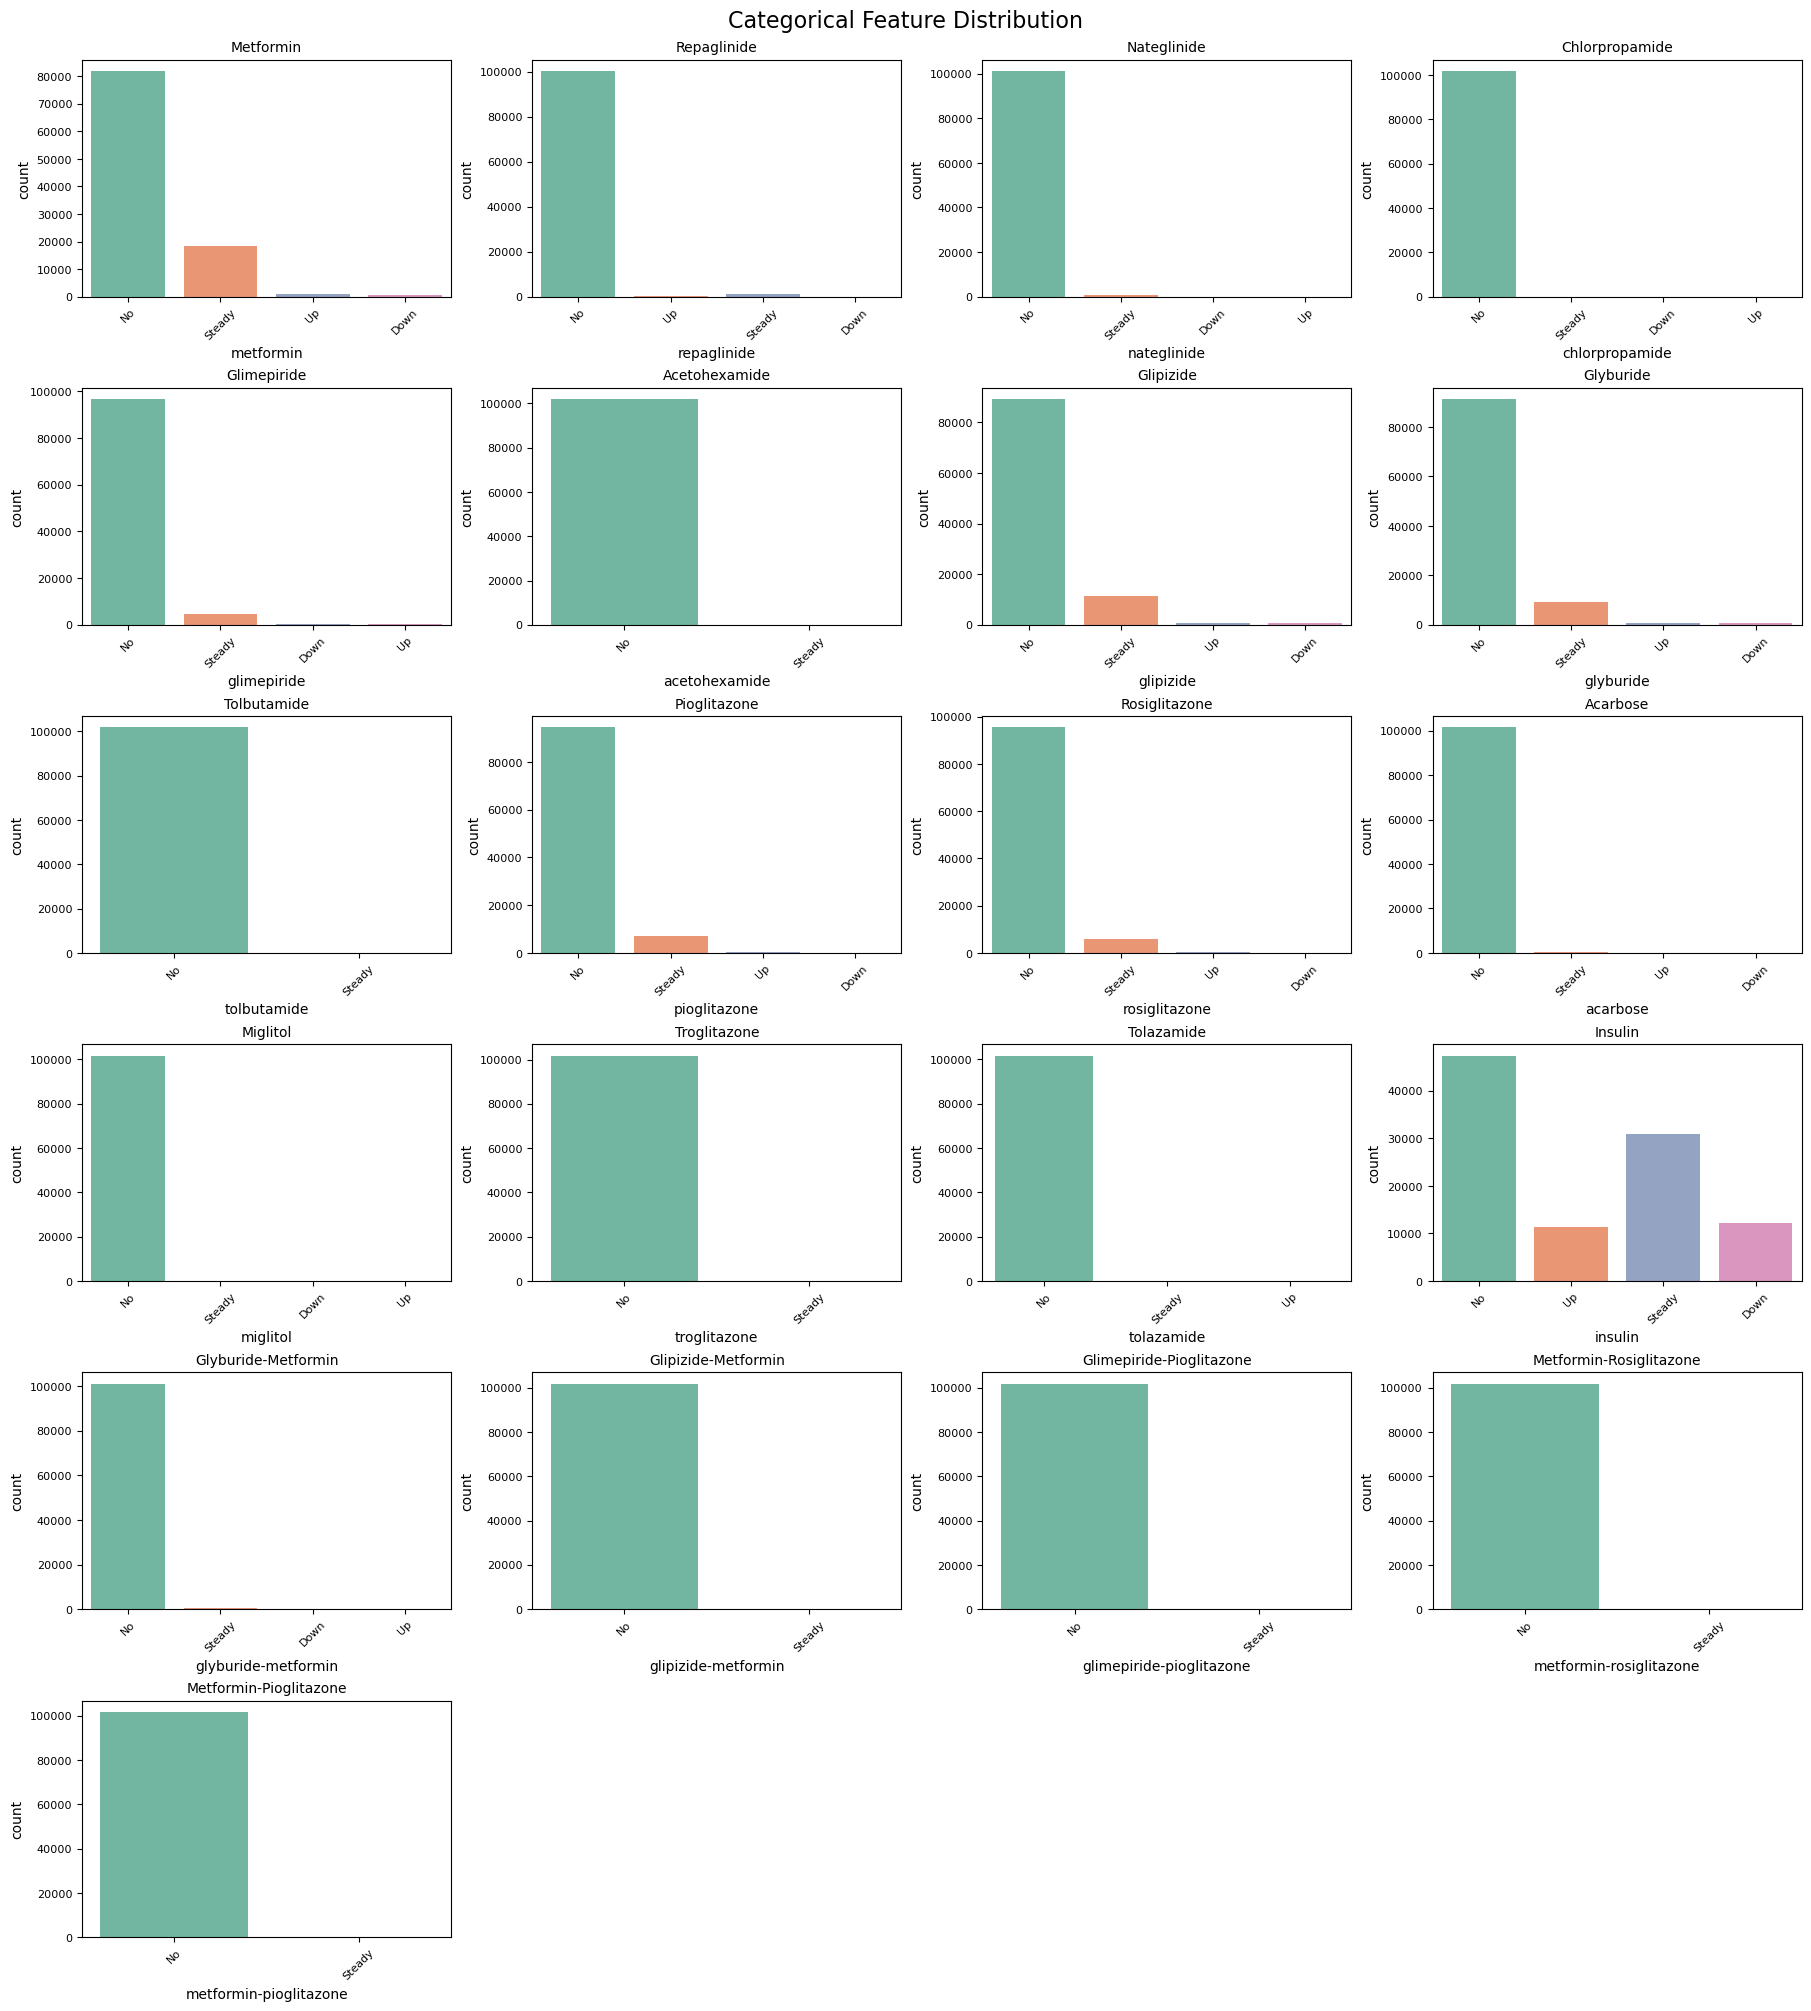

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Number of rows and columns in the grid
nrows = 6
ncols = 4

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 20), constrained_layout=True)

# Flatten axs array to iterate easily
axs = axs.flatten()

for idx, feature in enumerate(drug):
    sns.countplot(data=df, x=feature, ax=axs[idx], palette='Set2')
    axs[idx].set_title(feature.replace('_',' ').title(), fontsize=10)
    axs[idx].tick_params(axis='x', rotation=45, labelsize=8)
    axs[idx].tick_params(axis='y', labelsize=8)

# Remove any extra empty subplots
for j in range(len(drug), len(axs)):
    fig.delaxes(axs[j])

plt.suptitle('Categorical Feature Distribution', fontsize=16)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_14052\3920118965.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='A1Cresult', palette='Set2')


<Axes: xlabel='A1Cresult', ylabel='count'>

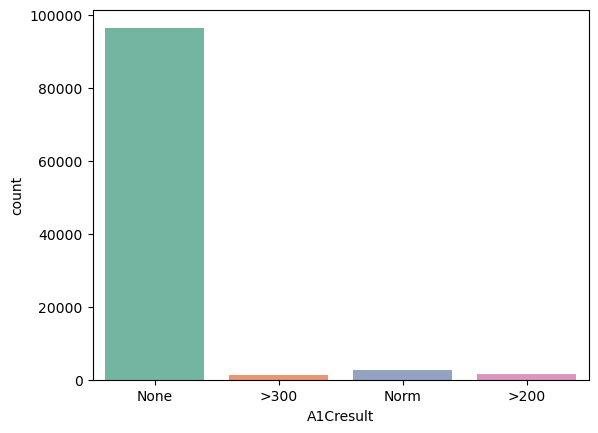

In [52]:
measurements= ['A1Cresult' ,'max_glu_serum']
sns.countplot(data=df, x='A1Cresult', palette='Set2')

C:\Users\User\AppData\Local\Temp\ipykernel_14052\1871549393.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='max_glu_serum', palette='Set2')


<Axes: xlabel='max_glu_serum', ylabel='count'>

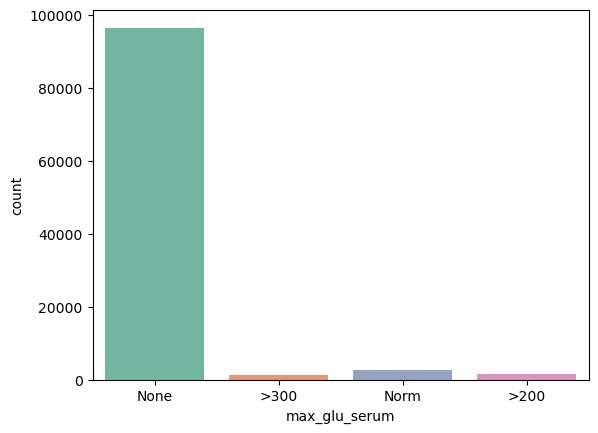

In [53]:
sns.countplot(data=df, x='max_glu_serum', palette='Set2')

### Preparation

**Internal Medicine Group:**
InternalMedicine, Family/GeneralPractice, Hospitalist, PhysicianNotFound, Resident

**Emergency:**
Emergency/Trauma

**Cardiology:**
Cardiology, Cardiology-Pediatric, Surgery-Cardiovascular, Surgery-Cardiovascular/Thoracic

**Surgical:**
Surgery-General, Surgeon, SurgicalSpecialty, Surgery-Thoracic, Surgery-Vascular, Surgery-Neuro, Surgery-Plastic, Surgery-Maxillofacial, Surgery-Colon&Rectal, Surgery-Pediatric, Surgery-PlasticwithinHeadandNeck, Proctology

**Orthopedics**
Orthopedics, Orthopedics-Reconstructive

**Pulmonary:**
Pulmonology

**Neurology:**
Neurology, Neurophysiology

**Oncology / Hematology:**
Oncology, Hematology, Hematology/Oncology, Pediatrics-Hematology-Oncology

**Pediatrics:**
Pediatrics, Pediatrics-Endocrinology, Pediatrics-CriticalCare, Pediatrics-Neurology, Pediatrics-Pulmonology, Pediatrics-EmergencyMedicine, Pediatrics-AllergyandImmunology, Pediatrics-InfectiousDiseases

**Obstetrics & Gynecology:**
ObstetricsandGynecology, Obstetrics, Gynecology, Obsterics&Gynecology-GynecologicOnco, Perinatology

**Endocrinology:**
Endocrinology, Endocrinology-Metabolism

**Psychiatry:**
Psychiatry, Psychiatry-Child/Adolescent, Psychiatry-Addictive, Psychology

**Radiology:**
Radiologist, Radiology

**Other Specialty:**
Rheumatology, Pathology, InfectiousDiseases, Dentistry, Dermatology, SportsMedicine, Speech, AllergyandImmunology, and all other rare specialties

In [56]:
def group_medical_specialty(df, col='medical_specialty'):
    # Define the groups
    internal_medicine = [
        'InternalMedicine', 'Family/GeneralPractice', 'Hospitalist', 'PhysicianNotFound', 'Resident'
    ]
    emergency = ['Emergency/Trauma']
    cardiology = [
        'Cardiology', 'Cardiology-Pediatric', 'Surgery-Cardiovascular', 'Surgery-Cardiovascular/Thoracic'
    ]
    surgical = [
        'Surgery-General', 'Surgeon', 'SurgicalSpecialty', 'Surgery-Thoracic', 'Surgery-Vascular',
        'Surgery-Neuro', 'Surgery-Plastic', 'Surgery-Maxillofacial', 'Surgery-Colon&Rectal',
        'Surgery-Pediatric', 'Surgery-PlasticwithinHeadandNeck', 'Proctology'
    ]
    orthopedics = ['Orthopedics', 'Orthopedics-Reconstructive']
    pulmonary = ['Pulmonology']
    neurology = ['Neurology', 'Neurophysiology']
    oncology_hematology = ['Oncology', 'Hematology', 'Hematology/Oncology', 'Pediatrics-Hematology-Oncology']
    pediatrics = [
        'Pediatrics', 'Pediatrics-Endocrinology', 'Pediatrics-CriticalCare', 'Pediatrics-Neurology',
        'Pediatrics-Pulmonology', 'Pediatrics-EmergencyMedicine', 'Pediatrics-AllergyandImmunology',
        'Pediatrics-InfectiousDiseases'
    ]
    obstetrics_gynecology = [
        'ObstetricsandGynecology', 'Obstetrics', 'Gynecology', 'Obsterics&Gynecology-GynecologicOnco', 'Perinatology'
    ]
    endocrinology = ['Endocrinology', 'Endocrinology-Metabolism']
    psychiatry = ['Psychiatry', 'Psychiatry-Child/Adolescent', 'Psychiatry-Addictive', 'Psychology']
    radiology = ['Radiologist', 'Radiology']

    # Create a function to map specialty to group
    def map_specialty(specialty):
        if specialty == 'Unknown':
            return 'Unknown'
        elif specialty in internal_medicine:
            return 'InternalMedicine'
        elif specialty in emergency:
            return 'Emergency'
        elif specialty in cardiology:
            return 'Cardiology'
        elif specialty in surgical:
            return 'Surgical'
        elif specialty in orthopedics:
            return 'Orthopedics'
        elif specialty in pulmonary:
            return 'Pulmonary'
        elif specialty in neurology:
            return 'Neurology'
        elif specialty in oncology_hematology:
            return 'Oncology_Hematology'
        elif specialty in pediatrics:
            return 'Pediatrics'
        elif specialty in obstetrics_gynecology:
            return 'Obstetrics_Gynecology'
        elif specialty in endocrinology:
            return 'Endocrinology'
        elif specialty in psychiatry:
            return 'Psychiatry'
        elif specialty in radiology:
            return 'Radiology'
        else:
            return 'Other'
             # Apply mapping to create a new grouped column
    df[col + '_grouped'] = df[col].apply(map_specialty)

    return df


In [57]:
df = group_medical_specialty(df)
df = df.drop(['medical_specialty'], axis = 1)
print(df['medical_specialty_grouped'].value_counts())


medical_specialty_grouped
Unknown                  49947
InternalMedicine         22145
Emergency                 7565
Cardiology                6108
Surgical                  4360
Other                     3689
Orthopedics               2633
Radiology                 1193
Psychiatry                 963
Pulmonary                  871
Obstetrics_Gynecology      774
Oncology_Hematology        641
Pediatrics                 542
Neurology                  204
Endocrinology              128
Name: count, dtype: int64


In [58]:
#Get Systems for ICD9
def getICD(i):
    if i== "Unknown"or 'V' in str(i) or 'E' in str(i):
        return 0
    i = float(i)
    if (i >= 390 and i < 460) or np.floor(i) == 785:
        return 1
    elif (i >= 460 and i < 520) or np.floor(i) == 786:
        return 2
    elif (i >= 520 and i < 580) or np.floor(i) == 787:
        return 3
    elif np.floor(i) == 250:
        return 4
    elif i >= 800 and i < 1000:
        return 5
    elif i >= 710 and i < 740:
        return 6
    elif (i >= 580 and i <= 630) or np.floor(i) == 788:
        return 7
    elif i >= 140 and i <= 240:
        return 8
    else:
        return 0

In [59]:
df['primary_diag'] = df['diag_1'].apply(getICD).astype(int)
df['secondary_diag'] = df['diag_2'].apply(getICD).astype(int)
df['additional_diag'] = df['diag_3'].apply(getICD).astype(int)

In [60]:
df[['diag_1','primary_diag' , 'diag_2','secondary_diag' ,'diag_3', 'additional_diag' ]].head(15).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
diag_1,250.83,276,648,8,197,414,414,428,398,434,250.7,157,428,428,518
primary_diag,4,0,0,0,8,1,1,1,1,1,4,8,1,1,2
diag_2,Unknown,250.01,250,250.43,157,411,411,492,427,198,403,288,250.43,411,998
secondary_diag,0,4,4,4,8,1,1,2,1,8,1,0,4,1,5
diag_3,Unknown,255,V27,403,250,250,V45,250,38,486,996,197,250.6,427,627
additional_diag,0,0,0,1,4,4,0,4,0,2,5,8,4,1,7


### encoding

admission_type_id	description:
1	Emergency
2	Urgent
3	Elective
4	Newborn
5	Not Available
6	NULL
7	Trauma Center
8	Not Mapped

discharge_disposition_id	description:
1	Discharged to home
2	Discharged/transferred to another short term hospital
3	Discharged/transferred to SNF
4	Discharged/transferred to ICF
5	Discharged/transferred to another type of inpatient care institution
6	Discharged/transferred to home with home health service
7	Left AMA
8	Discharged/transferred to home under care of Home IV provider
9	Admitted as an inpatient to this hospital
10	Neonate discharged to another hospital for neonatal aftercare
11	Expired
12	Still patient or expected to return for outpatient services
13	Hospice / home
14	Hospice / medical facility
15	Discharged/transferred within this institution to Medicare approved swing bed
16	Discharged/transferred/referred another institution for outpatient services
17	Discharged/transferred/referred to this institution for outpatient services
18	NULL
19	Expired at home. Medicaid only, hospice.
20	Expired in a medical facility. Medicaid only, hospice.
21	Expired, place unknown. Medicaid only, hospice.
22	Discharged/transferred to another rehab fac including rehab units of a hospital .
23	Discharged/transferred to a long term care hospital.
24	Discharged/transferred to a nursing facility certified under Medicaid but not certified under Medicare.
25	Not Mapped
26	Unknown/Invalid
30	Discharged/transferred to another Type of Health Care Institution not Defined Elsewhere
27	Discharged/transferred to a federal health care facility.
28	Discharged/transferred/referred to a psychiatric hospital of psychiatric distinct part unit of a hospital
29	Discharged/transferred to a Critical Access Hospital (CAH).

admission_source_id	description:
1	 Physician Referral
2	Clinic Referral
3	HMO Referral
4	Transfer from a hospital
5	 Transfer from a Skilled Nursing Facility (SNF)
6	 Transfer from another health care facility
7	 Emergency Room
8	 Court/Law Enforcement
9	 Not Available
10	 Transfer from critial access hospital
11	Normal Delivery
12	 Premature Delivery
13	 Sick Baby
14	 Extramural Birth
15	Not Available
17	NULL
18	 Transfer From Another Home Health Agency
19	Readmission to Same Home Health Agency
20	 Not Mapped
21	Unknown/Invalid
22	 Transfer from hospital inpt/same fac reslt in a sep claim
23	 Born inside this hospital
24	 Born outside this hospital
25	 Transfer from Ambulatory Surgery Center
26	Transfer from Hospice


In [63]:
# Change admission type urgent and trauma into emergency
df['admission_type_id'].replace([2,7],1, inplace=True)

# Change admission type Null and not mapped into not available (5)
df['admission_type_id'].replace([6,8],5, inplace=True)

#Consolidate discharge disposition reason
df['discharge_disposition_id'].replace([6, 8, 9 , 13],1, inplace=True)                           #Home
df['discharge_disposition_id'].replace([3, 4, 5, 15, 22, 23, 24, 27,30],2, inplace=True)         #Another facility
df['discharge_disposition_id'].replace([12, 15, 16, 17],10, inplace=True)                        #outpatient
df['discharge_disposition_id'].replace([25, 26],18, inplace=True)                                #null
df = df[~df["discharge_disposition_id"].isin([11,19,20,21])]

#Consolidate admission source reason
df['admission_source_id'].replace([2,3],1, inplace=True)                                     #Referral
df['admission_source_id'].replace([5, 6, 10, 18, 22, 25], 4, inplace=True)                   #transfer
df['admission_source_id'].replace([15, 17, 20, 21], 9, inplace=True)                         #not available
df['admission_source_id'].replace([12, 13, 14], 11, inplace=True)                            #delivery

C:\Users\User\AppData\Local\Temp\ipykernel_14052\1943572585.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['admission_type_id'].replace([2,7],1, inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_14052\1943572585.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [64]:
print(
    df['admission_type_id'].value_counts(normalize=True, dropna=False),
    df['discharge_disposition_id'].value_counts(normalize=True, dropna=False),
    df['admission_source_id'].value_counts(normalize=True, dropna=False)
)

admission_type_id
1    0.710471
3    0.187172
5    0.102256
4    0.000100
Name: proportion, dtype: float64 discharge_disposition_id
1     0.735803
2     0.205782
18    0.046748
7     0.006223
14    0.003716
28    0.001388
10    0.000340
Name: proportion, dtype: float64 admission_source_id
7     0.562985
1     0.305551
9     0.069213
4     0.062051
8     0.000150
11    0.000050
Name: proportion, dtype: float64


In [65]:
#Organize the Categorical Variables
df.replace({'gender': {'Male': 1, 'Female' : 0}}, inplace=True)
df.replace({'change': {'Ch': 1, 'No' : 0}}, inplace=True)
df.replace({'diabetesMed': {'Yes': 1, 'No' : 0}}, inplace=True)

df.replace({'A1Cresult': {'>200': 2, '>300': 2, 'Norm': 1, 'None' : 0 }}, inplace=True)
df.replace({'max_glu_serum': {'>200': 2, '>300': 2, 'Norm': 1, 'None' : 0 }}, inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_14052\3005422525.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'gender': {'Male': 1, 'Female' : 0}}, inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_14052\3005422525.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'change': {'Ch': 1, 'No' : 0}}, inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_14052\3005422525.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old be

In [66]:
df['age'] = df['age'].replace({
    '[0-10)': 1, '[10-20)': 2, '[20-30)': 3, '[30-40)': 4,
    '[40-50)': 5, '[50-60)': 6, '[60-70)': 7, '[70-80)': 8,
    '[80-90)': 9, '[90-100)': 10
})

C:\Users\User\AppData\Local\Temp\ipykernel_14052\3931041194.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['age'] = df['age'].replace({


In [67]:
df['race'] = df['race'].replace({
    'Caucasian': 1, 'AfricanAmerican': 2, 'Hispanic': 3, 'Asian': 4,
    'Other': 5, 'Unknown': 6
})

C:\Users\User\AppData\Local\Temp\ipykernel_14052\2819210908.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['race'] = df['race'].replace({


## numeric

### EDA

In [70]:
import pandas as pd

# group by time_in_hospital and readmitted
counts = df.groupby(['time_in_hospital', 'readmitted']).size().unstack(fill_value=0)

# compute rate = readmitted / total
counts['readmission_rate'] = counts[1] / (counts[0] + counts[1])

print(counts.sort_values('readmission_rate', ascending=False))

readmitted            0     1  readmission_rate
time_in_hospital                               
10                 1954   336          0.146725
8                  3697   625          0.144609
9                  2515   412          0.140758
12                 1208   193          0.137759
14                  878   135          0.133268
7                  4992   752          0.130919
6                  6476   949          0.127811
13                 1024   149          0.127025
5                  8635  1199          0.121924
4                 12131  1644          0.119347
3                 15652  1894          0.107945
11                 1614   195          0.107794
2                 15264  1712          0.100848
1                 12714  1162          0.083742


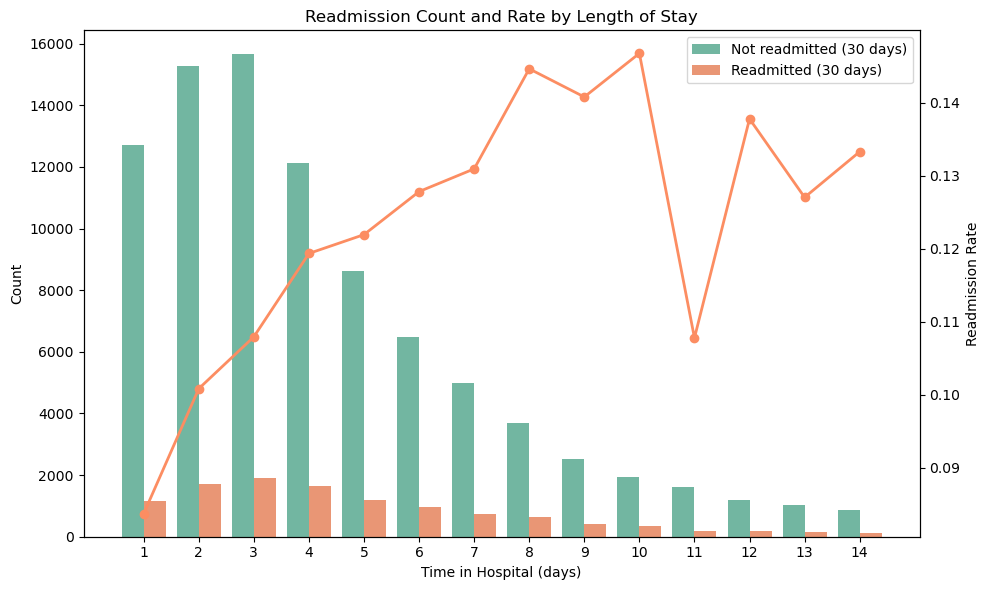

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

# Style (important for academic look)
#sns.set_style("whitegrid")
#sns.set_context("talk")  # or "paper" for smaller figures

# Prepare aggregated data
counts = df.groupby(['time_in_hospital', 'readmitted']).size().reset_index(name='count')
rates = df.groupby('time_in_hospital')['readmitted'].mean().reset_index(name='rate')

# Create figure
fig, ax1 = plt.subplots(figsize=(10,6))

# Bar plot (Seaborn)
sns.barplot(
    data=counts,
    x='time_in_hospital',
    y='count',
    hue='readmitted',
    palette='Set2',
    ax=ax1
)

ax1.set_ylabel('Count')
ax1.set_xlabel('Time in Hospital (days)')

# Secondary axis (Matplotlib)
ax2 = ax1.twinx()
ax2.plot(
    rates['time_in_hospital'] - 1,  # align with bars
    rates['rate'],
    color=sns.color_palette('Set2')[1],  # match readmitted=1
    marker='o',
    linewidth=2
)

ax1.grid(False)         # remove primary axis grid
ax2.grid(False)         # remove secondary axis grid
ax2.set_ylabel('Readmission Rate')
plt.title('Readmission Count and Rate by Length of Stay')
handles, _ = ax1.get_legend_handles_labels()
ax1.legend(handles, ['Not readmitted (30 days)', 'Readmitted (30 days)'])
plt.tight_layout()
plt.show()

<Axes: xlabel='admission_type_id', ylabel='count'>

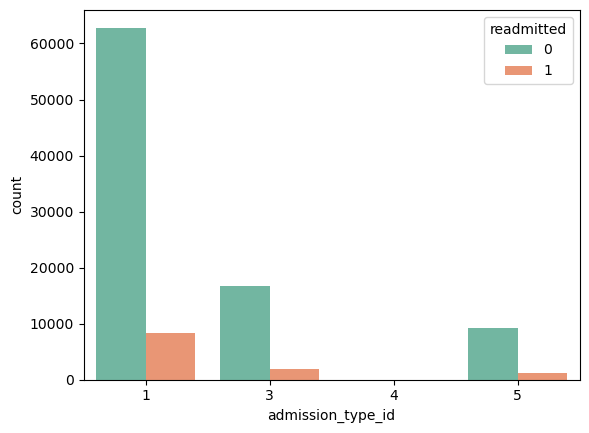

In [72]:
sns.countplot(data=df, x='admission_type_id', hue='readmitted', palette='Set2')


<Axes: xlabel='discharge_disposition_id', ylabel='count'>

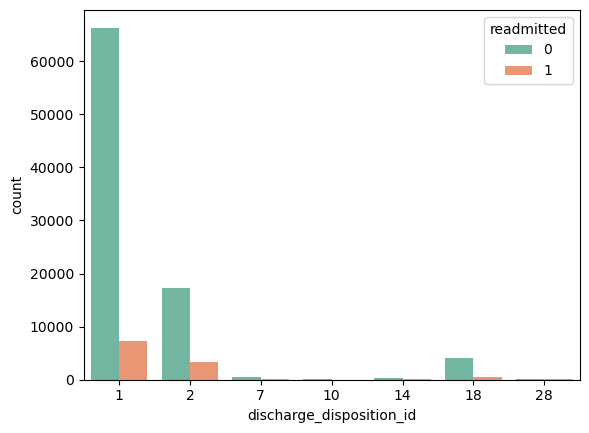

In [73]:
sns.countplot(data=df, x='discharge_disposition_id', hue='readmitted', palette='Set2')

<Axes: xlabel='admission_source_id', ylabel='count'>

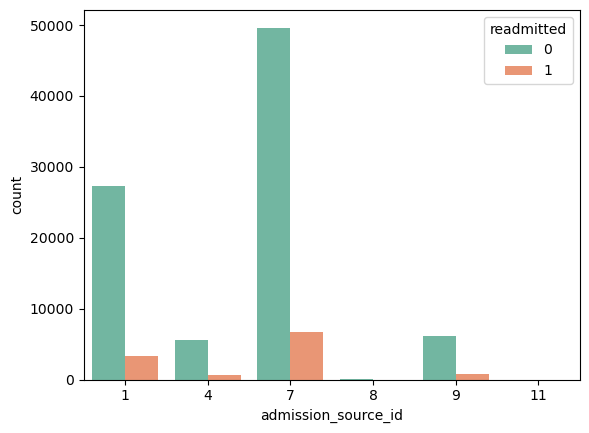

In [74]:
sns.countplot(data=df, x='admission_source_id', hue='readmitted', palette='Set2')

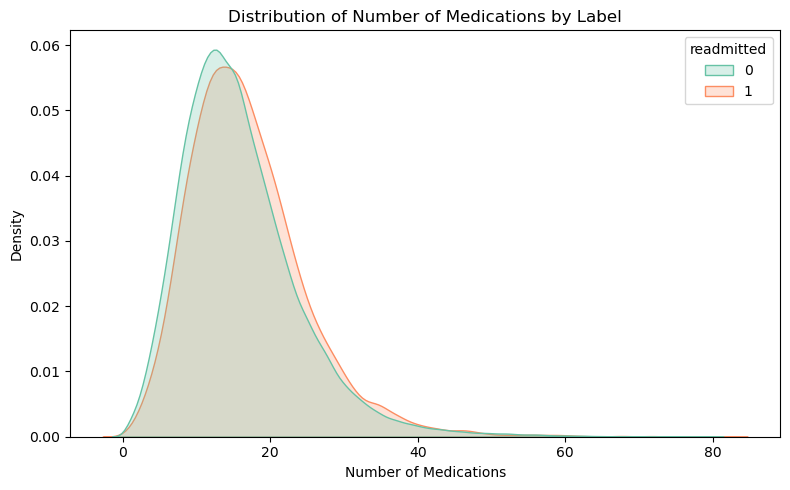

In [75]:
# KDE plot of num_medications by label
plt.figure(figsize=(8,5))
ax = plt.gca()
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Not readmitted (30 days)', 'Readmitted (30 days)'])

sns.kdeplot(
    data=df,
    x='num_medications',
    hue='readmitted',        # the class/label column
    fill=True,          # fills under the curve
    common_norm=False,  # normalize each curve independently
    palette='Set2',     # optional color palette
    bw_adjust=1,
    ax=ax
    # adjust bandwidth if needed
)
plt.xlabel('Number of Medications')
plt.ylabel('Density')
plt.title('Distribution of Number of Medications by Label')
plt.tight_layout()
plt.show()

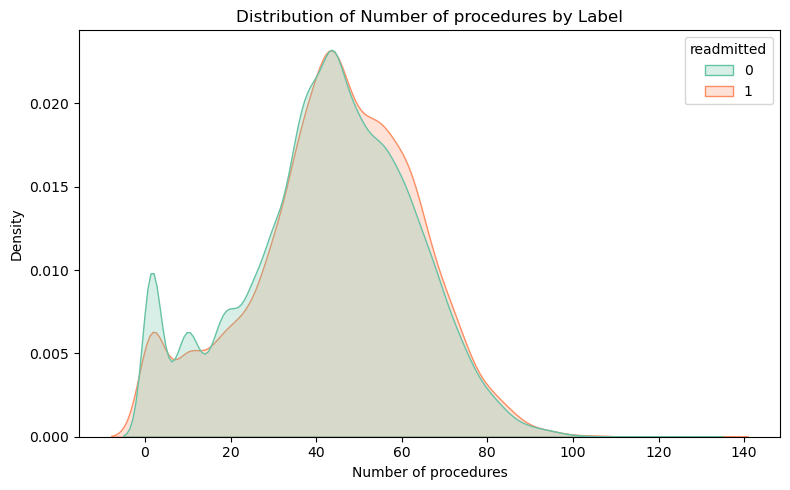

In [76]:
# KDE plot of num_medications by label
plt.figure(figsize=(8,5))
sns.kdeplot(
    data=df,
    x='num_lab_procedures',
    hue='readmitted',        # the class/label column
    fill=True,          # fills under the curve
    common_norm=False,  # normalize each curve independently
    palette='Set2',     # optional color palette
    bw_adjust=1         # adjust bandwidth if needed
)
plt.xlabel('Number of procedures')
plt.ylabel('Density')
plt.title('Distribution of Number of procedures by Label')
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_14052\2329056516.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='num_procedures', palette='Set2')


<Axes: xlabel='num_procedures', ylabel='count'>

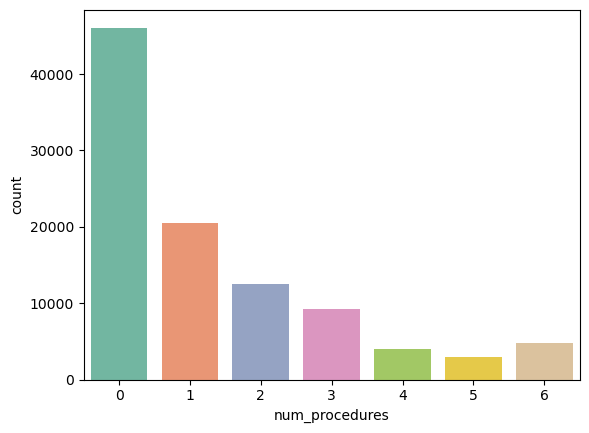

In [77]:
sns.countplot(data=df, x='num_procedures', palette='Set2')

In [78]:
print(df['encounter_id'].nunique())
print(df['patient_nbr'].nunique())

100111
70436


In [79]:
df['number_emergency'].value_counts()

number_emergency
0     88922
1      7538
2      2005
3       713
4       371
5       190
6        93
7        73
8        50
10       34
9        33
11       23
13       12
12       10
22        6
16        5
18        5
19        4
20        4
15        3
14        3
25        2
21        2
28        1
42        1
46        1
76        1
37        1
64        1
63        1
54        1
24        1
29        1
Name: count, dtype: int64

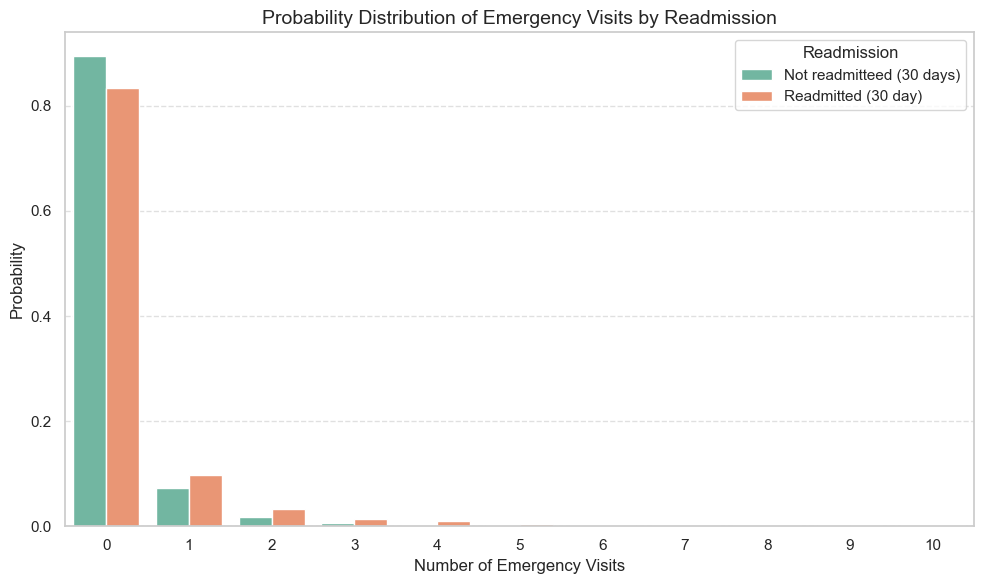

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")
sns.set_palette("Set2")

# Ensure full range 0–10
visit_range = np.arange(0, 11)

# Compute probabilities
prob_0 = (
    df[df['readmitted'] == 0]['number_emergency']
    .value_counts(normalize=True)
    .reindex(visit_range, fill_value=0)
)

prob_1 = (
    df[df['readmitted'] == 1]['number_emergency']
    .value_counts(normalize=True)
    .reindex(visit_range, fill_value=0)
)

# Convert to DataFrame for seaborn
plot_df = pd.DataFrame({
    'visits': np.tile(visit_range, 2),
    'probability': np.concatenate([prob_0.values, prob_1.values]),
    'Readmission': ['Not readmitteed (30 days)'] * len(visit_range) + ['Readmitted (30 day)'] * len(visit_range)
})

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_df,
    x='visits',
    y='probability',
    hue='Readmission'
)

# Labels & formatting
plt.xlabel('Number of Emergency Visits', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.title('Probability Distribution of Emergency Visits by Readmission', fontsize=14)


plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

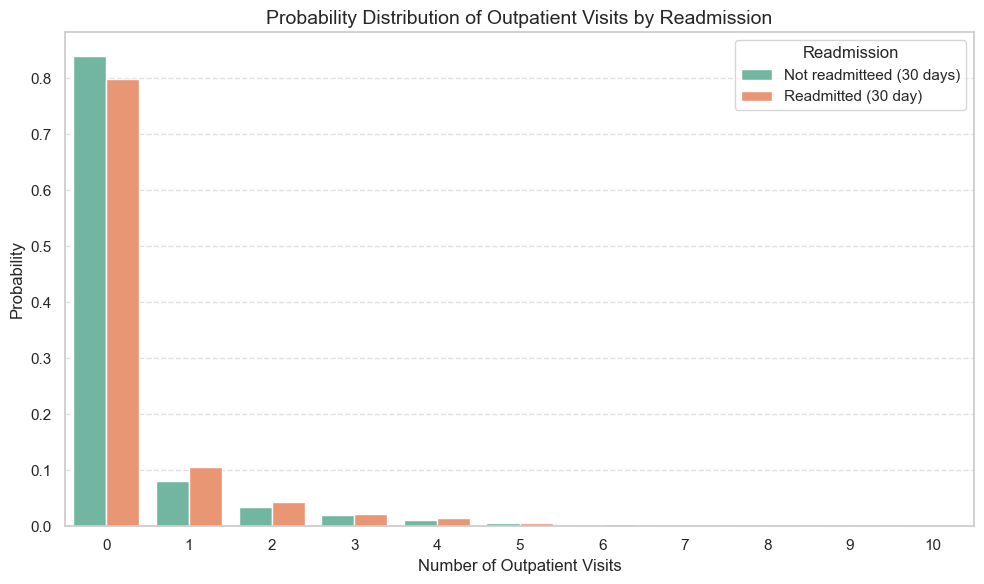

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")
sns.set_palette("Set2")

# Ensure full range 0–10
visit_range = np.arange(0, 11)

# Compute probabilities
prob_0 = (
    df[df['readmitted'] == 0]['number_outpatient']
    .value_counts(normalize=True)
    .reindex(visit_range, fill_value=0)
)

prob_1 = (
    df[df['readmitted'] == 1]['number_outpatient']
    .value_counts(normalize=True)
    .reindex(visit_range, fill_value=0)
)

# Convert to DataFrame for seaborn
plot_df = pd.DataFrame({
    'visits': np.tile(visit_range, 2),
    'probability': np.concatenate([prob_0.values, prob_1.values]),
    'Readmission': ['Not readmitteed (30 days)'] * len(visit_range) + ['Readmitted (30 day)'] * len(visit_range)
})

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_df,
    x='visits',
    y='probability',
    hue='Readmission'
)

# Labels & formatting
plt.xlabel('Number of Outpatient Visits', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.title('Probability Distribution of Outpatient Visits by Readmission', fontsize=14)


plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

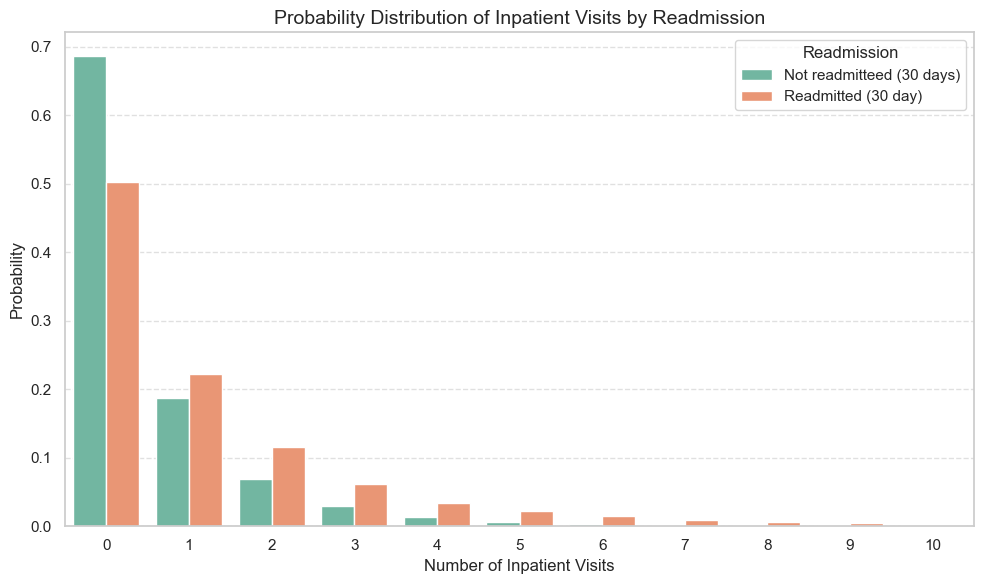

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")
sns.set_palette("Set2")

# Ensure full range 0–10
visit_range = np.arange(0, 11)

# Compute probabilities
prob_0 = (
    df[df['readmitted'] == 0]['number_inpatient']
    .value_counts(normalize=True)
    .reindex(visit_range, fill_value=0)
)

prob_1 = (
    df[df['readmitted'] == 1]['number_inpatient']
    .value_counts(normalize=True)
    .reindex(visit_range, fill_value=0)
)

# Convert to DataFrame for seaborn
plot_df = pd.DataFrame({
    'visits': np.tile(visit_range, 2),
    'probability': np.concatenate([prob_0.values, prob_1.values]),
    'Readmission': ['Not readmitteed (30 days)'] * len(visit_range) + ['Readmitted (30 day)'] * len(visit_range)
})

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_df,
    x='visits',
    y='probability',
    hue='Readmission'
)

# Labels & formatting
plt.xlabel('Number of Inpatient Visits', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.title('Probability Distribution of Inpatient Visits by Readmission', fontsize=14)


plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

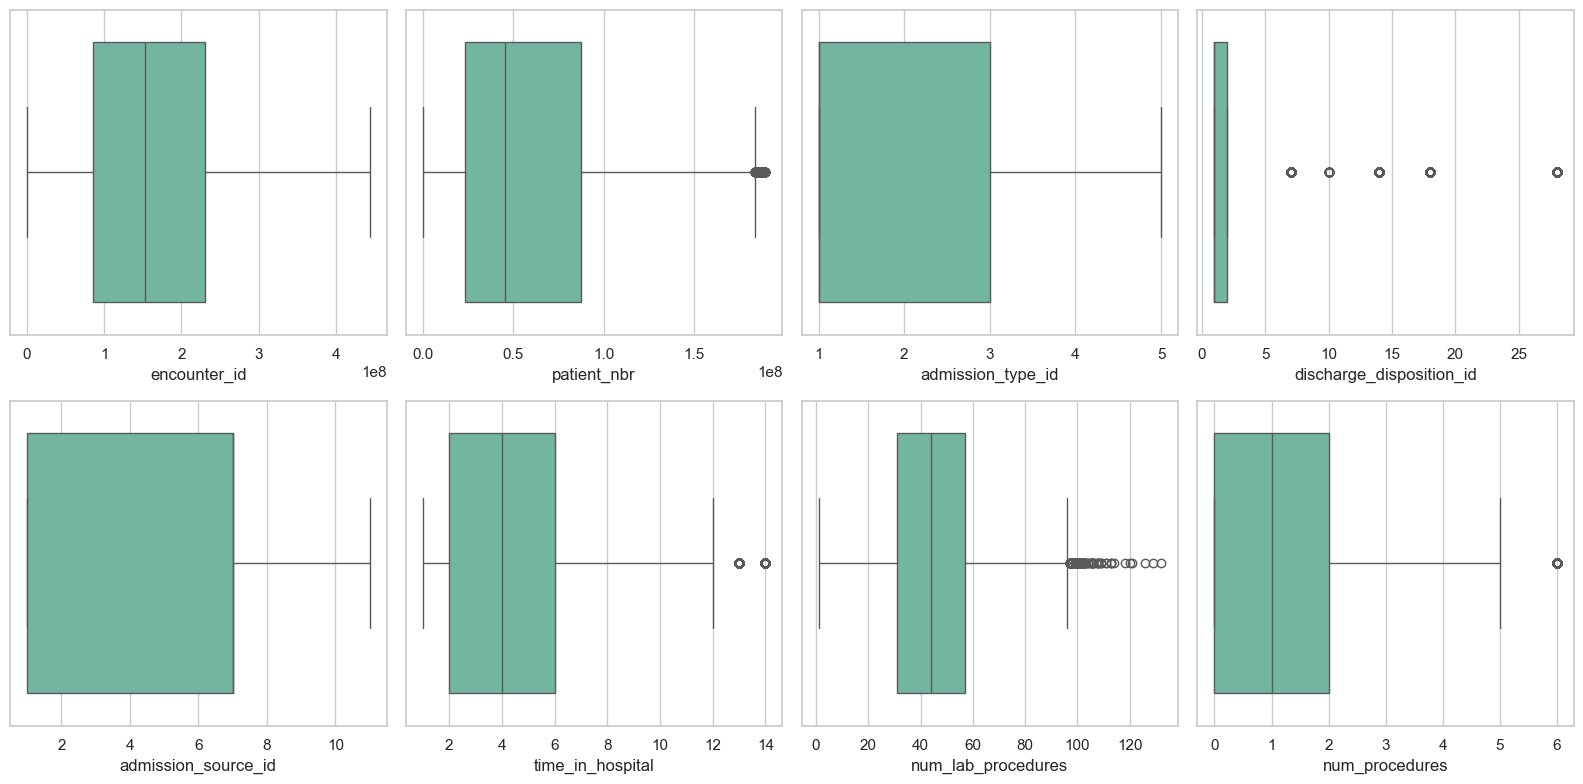

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

def boxplot_for_outlier(df, columns):
    count = 0
    fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(16,8))

    set2_color = sns.color_palette("Set2")[0]  # pick one color

    for i in range(2):
        for j in range(4):
            sns.boxplot(
                x=df[columns[count]],
                color=set2_color,   # same color for all
                ax=ax[i][j]
            )
            count += 1

    plt.tight_layout()

boxplot_for_outlier(df, numerical_cols)

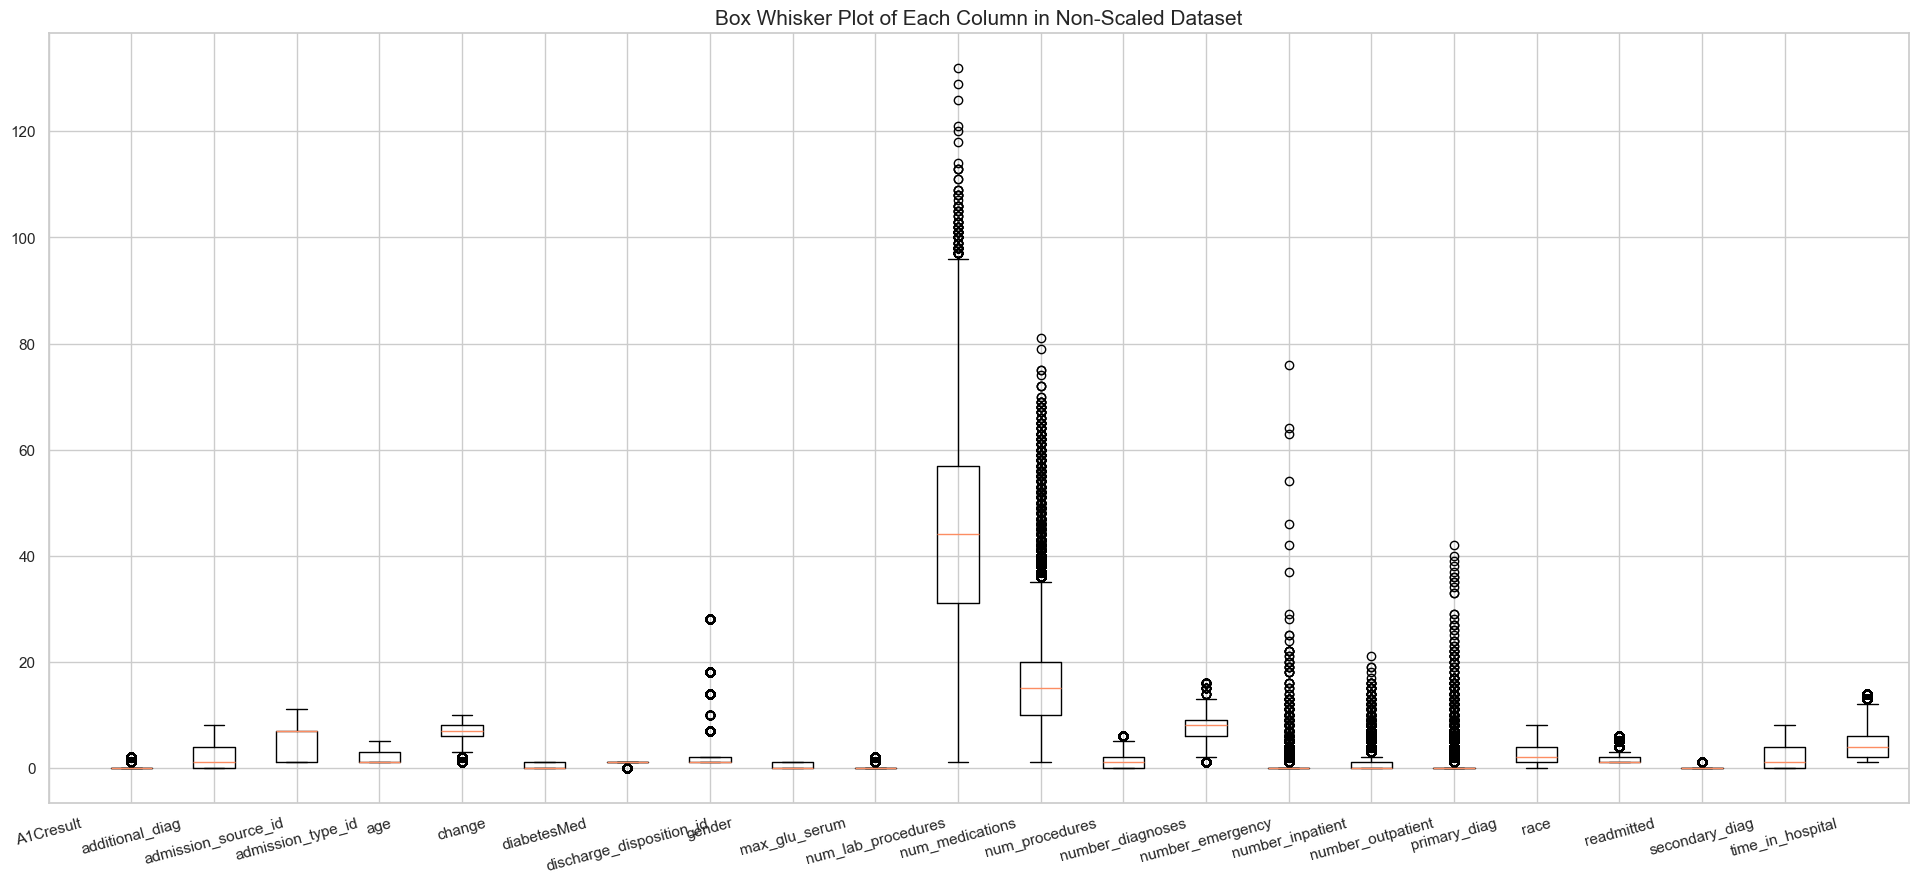

In [84]:
#Check the spread of values (standardize the data for modeling)
num_feat = df[df.columns.difference(['encounter_id', 'patient_nbr'])].select_dtypes(include=[np.number])
plt.figure(figsize=(24, 10))
plt.boxplot([num_feat[col] for col in num_feat.columns])
plt.title("Box Whisker Plot of Each Column in Non-Scaled Dataset", fontsize=15)
plt.xticks(range(len(num_feat.columns.values)), num_feat.columns.values, rotation = 15)
plt.show()

### Outlier And Correlation

In [86]:
print("\n=================== Outliers =======================")
for col in numerical_cols:
    v = df[col]
    q1 = v.quantile(0.25)
    q3 = v.quantile(0.75)
    iqr = q3 - q1
    outliers = v[(v <= q1 - 1.5 * iqr) | (v >= q3 + 1.5 * iqr)]
    perc = len(outliers) * 100.0 / len(df)
    print(f"{col} outliers = {perc:.2f}%")

    print("\n=================== Skewness & Kurtosis =======================")

for col in numerical_cols:
    print(col, "Skew is:", df[col].skew(), "Kurtosis is:", df[col].kurtosis())


=================== Outliers =======================
encounter_id outliers = 0.00%

=================== Skewness & Kurtosis =======================
patient_nbr outliers = 0.24%

=================== Skewness & Kurtosis =======================
admission_type_id outliers = 0.00%

=================== Skewness & Kurtosis =======================
discharge_disposition_id outliers = 5.84%

=================== Skewness & Kurtosis =======================
admission_source_id outliers = 0.00%

=================== Skewness & Kurtosis =======================
time_in_hospital outliers = 3.58%

=================== Skewness & Kurtosis =======================
num_lab_procedures outliers = 0.15%

=================== Skewness & Kurtosis =======================
num_procedures outliers = 7.80%

=================== Skewness & Kurtosis =======================
num_medications outliers = 2.84%

=================== Skewness & Kurtosis =======================
number_outpatient outliers = 100.00%

===============

If skewness is less than -1 or greater than 1, the distribution is highly skewed.
If skewness is between -1 and -0.5 or between 0.5 and 1, the distribution is moderately skewed.
If skewness is between -0.5 and 0.5, the distribution is approximately symmetric.

There are features with high kurtosis and highly skewed that would impact standardization namely:

number_outpatient with skew of 9.65 and kurtosis of 183.15
number_emergency with skew of 21.20 and kurtosis of 1204.28
number_inpatient with skew of 5.47 and kurtosis of 45.25

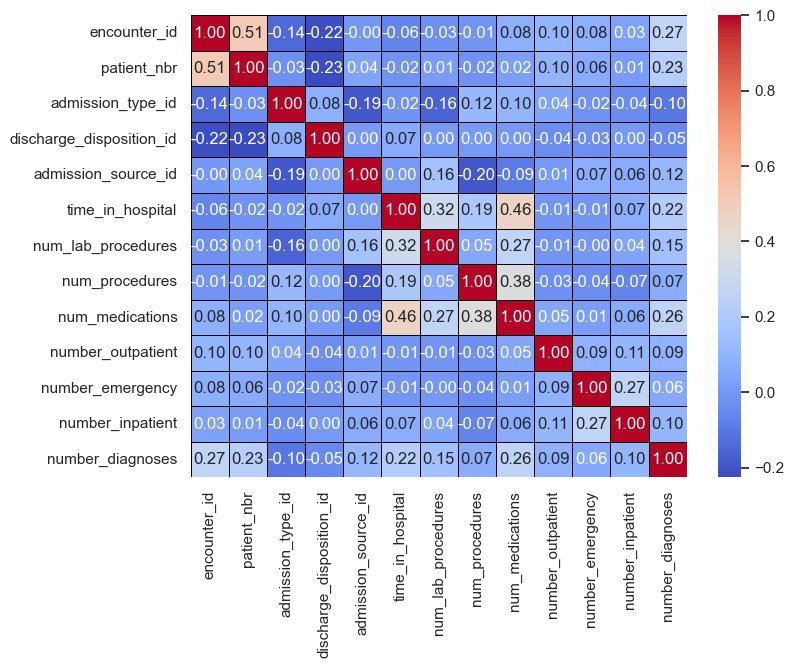

In [88]:
f,ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, linewidths=0.5,linecolor="black", fmt= '.2f',ax=ax,cmap="coolwarm")
plt.show()

## Data Engineering

Medication Change (med_change)

The dataset contains variables for the prescription status of multiple diabetes medications during each hospital encounter. Each medication can have values such as up (dose increased), down (dose decreased), steady (dose unchanged), or no (medication not prescribed).

To summarize the overall changes in diabetes treatment, we created a new variable called med_change. This feature indicates whether any adjustment in the patient’s diabetes medication regimen occurred during the hospital stay. The idea is that medication adjustments reflect clinical complexity and treatment instability.

We explored two versions of this feature:

Binary version (change) – indicates simply whether there was any medication change (change) or not (no change).

Numeric version (num_med) – counts the total number of medications that were adjusted (either up or down) during the encounter. A higher value suggests a more complex or unstable treatment course.


num_med = how many ingredients you used at all,

med_change = how many ingredients you changed the amount of while cooking.

In [92]:
df_med_change = df[drug].copy()
# Step 1: Convert all medication columns to 0/1 at once
df_med_change= df[drug].applymap(lambda x: 0 if x in ['No', 'Steady'] else 1).astype(int)

# Step 2: Sum across all medications to get med_change
df['med_change'] = df_med_change.sum(axis=1)

C:\Users\User\AppData\Local\Temp\ipykernel_14052\291912925.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_med_change= df[drug].applymap(lambda x: 0 if x in ['No', 'Steady'] else 1).astype(int)


In [93]:
# Check the status of the new feature med_change
df['med_change'].value_counts()

med_change
0    72861
1    25830
2     1308
3      107
4        5
Name: count, dtype: int64

In [94]:
df_num_med = df[drug].copy()
# Step 1: Convert all medication columns to 0/1 at once
df_num_med = df[drug].applymap(lambda x: 0 if x in 'No' else 1)

# Step 2: Sum across all medications to get med_change
df['num_med'] = df_num_med.sum(axis=1)

C:\Users\User\AppData\Local\Temp\ipykernel_14052\1332744201.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_num_med = df[drug].applymap(lambda x: 0 if x in 'No' else 1)


In [95]:
df['num_med'].value_counts()

num_med
1    46433
0    22841
2    21712
3     7737
4     1325
5       58
6        5
Name: count, dtype: int64

In [96]:
df[drug] = df[drug].applymap(lambda x: 0 if x == 'No' else 1)

C:\Users\User\AppData\Local\Temp\ipykernel_14052\347300252.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[drug] = df[drug].applymap(lambda x: 0 if x == 'No' else 1)


Service utilization: The data contains variables for number of inpatient (admissions), emergency room visits and outpatient visits for a given patient in the previous one year. These are (crude) measures of how much hospital/clinic services a person has used in the past year. added these three to create a new variable called service utilization. The idea was to see which version gives us better results. Granted, we did not apply any special weighting to the three ingredients of service utilization but we wanted to try something simple at this stage. so we combined these features into a new variable called Service utilization

In [98]:
df['service_utilization'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']  #year_visits

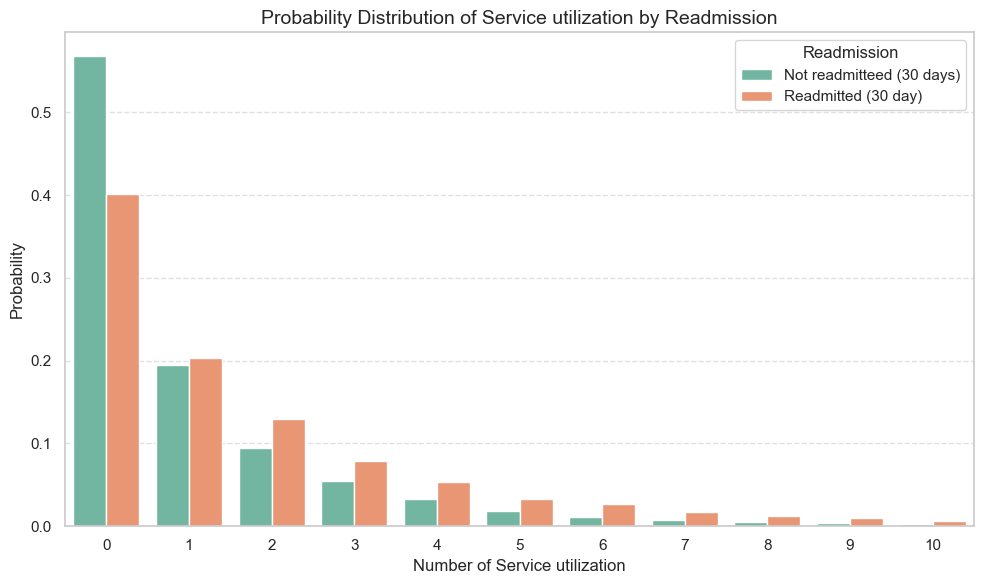

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")
sns.set_palette("Set2")

# Ensure full range 0–10
visit_range = np.arange(0, 11)

# Compute probabilities
prob_0 = (
    df[df['readmitted'] == 0]['service_utilization']
    .value_counts(normalize=True)
    .reindex(visit_range, fill_value=0)
)

prob_1 = (
    df[df['readmitted'] == 1]['service_utilization']
    .value_counts(normalize=True)
    .reindex(visit_range, fill_value=0)
)

# Convert to DataFrame for seaborn
plot_df = pd.DataFrame({
    'visits': np.tile(visit_range, 2),
    'probability': np.concatenate([prob_0.values, prob_1.values]),
    'Readmission': ['Not readmitteed (30 days)'] * len(visit_range) + ['Readmitted (30 day)'] * len(visit_range)
})

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_df,
    x='visits',
    y='probability',
    hue='Readmission'
)

# Labels & formatting
plt.xlabel('Number of Service utilization', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.title('Probability Distribution of Service utilization by Readmission', fontsize=14)


plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [100]:
df = df.drop(['diag_1', 'diag_2','diag_3'], axis = 1)

## re-typing

In [102]:
df.dtypes

encounter_id                  int64
patient_nbr                   int64
race                          int64
gender                        int64
age                           int64
admission_type_id             int64
discharge_disposition_id      int64
admission_source_id           int64
time_in_hospital              int64
num_lab_procedures            int64
num_procedures                int64
num_medications               int64
number_outpatient             int64
number_emergency              int64
number_inpatient              int64
number_diagnoses              int64
max_glu_serum                 int64
A1Cresult                     int64
metformin                     int64
repaglinide                   int64
nateglinide                   int64
chlorpropamide                int64
glimepiride                   int64
acetohexamide                 int64
glipizide                     int64
glyburide                     int64
tolbutamide                   int64
pioglitazone                

In [103]:
# convert data type of nominal features in dataframe to 'object' type
i = ['race','gender','age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id',\
          'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', \
          'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose','miglitol', \
          'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', \
          'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', \
          'max_glu_serum', 'medical_specialty_grouped','primary_diag', 'secondary_diag', 'additional_diag']

df[i] = df[i].astype('object')

In [104]:
df.dtypes

encounter_id                  int64
patient_nbr                   int64
race                         object
gender                       object
age                          object
admission_type_id            object
discharge_disposition_id     object
admission_source_id          object
time_in_hospital              int64
num_lab_procedures            int64
num_procedures                int64
num_medications               int64
number_outpatient             int64
number_emergency              int64
number_inpatient              int64
number_diagnoses              int64
max_glu_serum                object
A1Cresult                    object
metformin                    object
repaglinide                  object
nateglinide                  object
chlorpropamide               object
glimepiride                  object
acetohexamide                object
glipizide                    object
glyburide                    object
tolbutamide                  object
pioglitazone                

In [105]:
for i in df.columns:
    if df[i].dtype==object:
        d= df[i].value_counts()
        print(pd.DataFrame(data=d))

      count
race       
1     74845
2     18888
6      2237
3      2024
5      1485
4       632
        count
gender       
0       53861
1       46250
     count
age       
8    25560
7    22184
6    17102
9    16706
5     9626
4     3765
10    2668
3     1650
2      690
1      160
                   count
admission_type_id       
1                  71126
3                  18738
5                  10237
4                     10
                          count
discharge_disposition_id       
1                         73662
2                         20601
18                         4680
7                           623
14                          372
28                          139
10                           34
                     count
admission_source_id       
7                    56361
1                    30589
9                     6929
4                     6212
8                       15
11                       5
               count
max_glu_serum       
0              94887

In [106]:
num_col = list(set(list(df._get_numeric_data().columns)))
num_col

['num_med',
 'num_medications',
 'number_diagnoses',
 'readmitted',
 'time_in_hospital',
 'service_utilization',
 'med_change',
 'patient_nbr',
 'encounter_id',
 'num_procedures',
 'number_outpatient',
 'num_lab_procedures',
 'number_emergency',
 'number_inpatient']

In [107]:
# Numeric features
numeric_cols = [
    'number_diagnoses',
    'num_lab_procedures',
    'num_med',
    'time_in_hospital',
    'med_change',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'service_utilization',
    'num_procedures'
]

# Object / categorical columns
categorical_cols = [
    'race',
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id',
    'max_glu_serum',
    'medical_specialty_grouped',
    'gender',
    'age',
    'primary_diag'
]
for col in categorical_cols:
    df[col] = df[col].astype(str)

In [108]:
i = ['diabetesMed','change','metformin','age', 'repaglinide','gender', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', \
          'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose','miglitol', \
          'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', \
          'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone','A1Cresult','secondary_diag','additional_diag']
df[i] = df[i].astype('int64')

In [109]:
df = df.drop(['metformin-pioglitazone','metformin-rosiglitazone' ,'glimepiride-pioglitazone','glipizide-metformin','glyburide-metformin','tolazamide','miglitol','acarbose','tolbutamide','acetohexamide','chlorpropamide','nateglinide'], axis = 1)

## Export data set

In [111]:
df.head().T

,0,1,2,3,4
encounter_id,2278392,149190,64410,500364,16680
patient_nbr,8222157,55629189,86047875,82442376,42519267
race,1,1,2,1,1
gender,0,0,0,1,1
age,1,2,3,4,5
admission_type_id,5,1,1,1,1
discharge_disposition_id,18,1,1,1,1
admission_source_id,1,7,7,7,7
time_in_hospital,1,3,2,2,1
num_lab_procedures,41,59,11,44,51


In [112]:
# Export DataFrame to CSV
df.to_csv('preprocessing.csv', index=False)